In [ ]:
import xspec 
from datetime import datetime
import os
import sys
import numpy as np
from astropy.io import fits
import matplotlib
import matplotlib.pyplot as plt
import os
import pandas as pd
from datetime import datetime
from solexs_tools.solexs_genspec import solexs_genspec
from tqdm.notebook import tqdm as tqdm
import scienceplots

plt.style.use(['science','no-latex'])
plt.plot(); plt.close();

In [2]:
gti_filename = '/home/idies/workspace/sciserver_cookbooks/SoLEXS/Data/AL1_SLX_L1_20241001_v1.0/SDD2/AL1_SOLEXS_20241001_SDD2_L1.gti.gz'
lc_filename = '/home/idies/workspace/sciserver_cookbooks/SoLEXS/Data/AL1_SLX_L1_20241001_v1.0/SDD2/AL1_SOLEXS_20241001_SDD2_L1.lc.gz'
pi_filename = '/home/idies/workspace/sciserver_cookbooks/SoLEXS/Data/AL1_SLX_L1_20241001_v1.0/SDD2/AL1_SOLEXS_20241001_SDD2_L1.pi.gz'


In [3]:
spec_txt_path = "/home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Spectral_data/spectral_data_file_paths.txt"


## Spectral Fitting

In [ ]:
output_plots_dir = '/home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Fitting_plots'
output_results_dir = '/home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Fitting_data_results'

# Create directories if they don't exist
os.makedirs(output_plots_dir, exist_ok=True)
os.makedirs(output_results_dir, exist_ok=True)

tstart_array = []
tstop_array = []

# Read all spectral file paths
with open(spec_txt_path, 'r') as f:
    spec_files = f.readlines()
spec_files = [f.strip() for f in spec_files]  # Remove any whitespace/newlines

# Create a list to store fitting results
fitting_results = []

# Load the custom model
xspec.AllModels.lmod('chspec',dirPath='/home/idies/workspace/sciserver_cookbooks/SoLEXS/Software/chspec-main/')

# Set systematic uncertainty
sys_unc = 0.04
xspec.AllModels.systematic = sys_unc

# Process each spectral file
for specfile in spec_files:
    try:
        # Clear existing data and modelsnp.nan
        xspec.AllData.clear()
        xspec.AllModels.clear()

        # Get base name without .pi extension
        specbase = specfile.split('.pi')[0]
        
        # Create output directory path
        
        Fitting_data_path = os.path.join(os.path.dirname(specfile), 'Fitting_data')
        os.makedirs(Fitting_data_path, exist_ok=True)
        
        
        spec_hdul = fits.open(specfile)

        tstart = spec_hdul[1].header.get('TSTART', None)
        tstop = spec_hdul[1].header.get('TSTOP', None)

        if tstart and tstop:
            try:
                tstart_dt = datetime.fromisoformat(tstart)
                tstop_dt = datetime.fromisoformat(tstop)
                terr_sec = (tstop_dt - tstart_dt).total_seconds()
            except ValueError as ve:
                print(f"Error parsing TSTART/TSTOP for {specfile}: {ve}")
                terr_sec = np.nan
        else:
            print(f"TSTART or TSTOP missing in {specfile}")
            terr_sec = np.nan
        
        tstart_array.append(tstart)
        tstop_array.append(tstop)
        spec_hdul.close()
        
        
        # Load spectrum
        spec = xspec.Spectrum(specfile)

        # Set up plotting
        xspec.Plot.device = '/gif'
        xspec.Plot.xAxis = 'keV'

        # Set energy range and handle NaN values
        energy_range = (2.8, 12.0)
        spec.ignore(f"**-{energy_range[0]} {energy_range[1]}-**")

        ene_cen = np.array([np.mean(energy_interval) for energy_interval in spec.energies])
        idx = np.where(np.isnan(np.array(spec.values)/np.array(spec.variance)))[0]
        if(len(idx)>0):
            ene_max = ene_cen[idx[0]]
            energy_range = (energy_range[0], ene_max)
            spec.ignore("**-{} {}-**".format(*energy_range))

        # Open log file
        log_file = os.path.join(output_results_dir, f'{os.path.basename(specbase)}_chisoth_log.txt')
        xspec.Xset.openLog(log_file)

        # Set up and perform fitting
        m1 = xspec.Model("chisoth+chisoth")
        
        #m1(1).values=[7]
        m1(18).link= m1(49)
        m1(20).link= m1(51)
        m1(26).link= m1(57)
        m1(28).link= m1(59)
        m1(18).frozen = False # Ar Abundance
        m1(20).frozen = False # Ca Abundance
        m1(26).frozen = False # Fe Abundance
        m1(28).frozen = False # Ni Abundance


        #xspec.Fit.nIterations = 1000
        xspec.Fit.query = 'yes'
        xspec.Fit.perform()
        #xspec.Fit.error("2.706 1 18 20 26 28 31")
        xspec.AllModels.show(parIDs="1 18 20 26 28 31")
        # Save parameters
        params = {
            'filename': os.path.basename(specfile),
            'tstart': tstart,
            'tstop': tstop,
            't_error': terr_sec,
            'temperature': m1(1).values[0],
            'temperature_error': m1(1).sigma,
            'Ar_abundance': m1(18).values[0],
            'Ar_abundance_error': m1(18).sigma,
            'Ca_abundance': m1(20).values[0],
            'Ca_abundance_error': m1(20).sigma,
            'Fe_abundance': m1(26).values[0],
            'Fe_abundance_error': m1(26).sigma,
            'Ni_abundance': m1(28).values[0],
            'Ni_abundance_error': m1(28).sigma,
            'EM': m1(31).values[0],
            'EM_error': m1(31).sigma,
            'chi_squared': xspec.Fit.statistic,
            'dof': xspec.Fit.dof,
            'reduced_chi_squared': xspec.Fit.statistic/xspec.Fit.dof
        }
        fitting_results.append(params)

        # You might also want to add these values to the plot title or legend
        #plt.suptitle(f'T = {params["temperature"]:.2f} keV, EM = {params["EM"]:.2e}', fontsize=fs)

        
        
        # Save XCM file
        fxcm = os.path.join(output_results_dir, f'{os.path.basename(specbase)}_chisoth_Fit.xcm')
        if os.path.isfile(fxcm):
            os.remove(fxcm)
        xspec.Xset.save(fxcm)

        # Create and save plot
        xspec.Plot('ld','delc')
        
        # Get plot data
        ene=xspec.Plot.x(plotGroup=1, plotWindow=1)
        eneErr=xspec.Plot.xErr(plotGroup=1, plotWindow=1)
        spec=xspec.Plot.y(plotGroup=1, plotWindow=1)
        specErr=xspec.Plot.yErr(plotGroup=1, plotWindow=1)
        fitmodel=xspec.Plot.model(plotGroup=1, plotWindow=1)
        delchi=xspec.Plot.y(plotGroup=1, plotWindow=2)
        delchiErr=xspec.Plot.yErr(plotGroup=1, plotWindow=2)

        # Create plot
        fs = 16
        fig0 = plt.figure(num=None, figsize=(14, 7), facecolor='w', edgecolor='k')

        # Upper panel
        ax0 = fig0.add_axes([0.15, 0.4, 0.8, 0.55])
        plt.errorbar(ene,spec,xerr=eneErr,yerr=specErr,fmt='.',ms=0.5,capsize=3.0,lw=1, label='Data', c='k')
        plt.step(ene,fitmodel,where='mid', label='CHIANTI Isothermal Model', c='b', linewidth=2)
        plt.yscale("log")
        plt.xlim(energy_range[0]-0.1, energy_range[1]+0.1)         
        plt.ylim([1e-1,1e4])
        plt.ylabel('Count rate (counts s$^{-1}$ keV$^{-1}$)', fontsize=fs)
        plt.legend(loc='upper right', fontsize=13)
        plt.xticks(fontsize=fs-2.5)
        plt.yticks(fontsize=fs-2.5)
        plt.grid(True)

        # Lower panel
        ax1 = fig0.add_axes([0.15, 0.15, 0.8, 0.25])
        plt.axhline(0,linestyle='dashed',color='black')
        plt.errorbar(ene,delchi,xerr=eneErr,yerr=delchiErr,fmt='.',ms=0.1,capsize=3.0,lw=1, c='k', 
                    label=r'$\chi^2_\nu$ = '+f'{(xspec.Fit.statistic/xspec.Fit.dof):.2f}')
        plt.axhline(0, c='limegreen')
        plt.legend()
        plt.xlim(energy_range[0]-0.1, energy_range[1]+0.1)         
        plt.ylabel('$\Delta \chi$', fontsize=fs)
        plt.xlabel('Energy (keV)', fontsize=fs)
        plt.xticks(fontsize=fs-4)
        plt.yticks(fontsize=fs-4)

        dymax = 6*(np.amax(delchi)//6 + 1)
        plt.ylim(-dymax,dymax)
        plt.grid(True)

        # Save plot
        plt.savefig(os.path.join(output_plots_dir, f'{os.path.basename(specbase)}_chisoth_Fit.png'), 
            bbox_inches='tight', facecolor='white', transparent=False)
        plt.close()

        xspec.Xset.closeLog()

    except Exception as e:
        print(f"Error processing file {specfile}: {str(e)}")
        continue

# Save fitting results to CSV
results_df = pd.DataFrame(fitting_results)
results_df.to_csv(os.path.join(output_results_dir, 'fitting_results.csv'), index=False)

print(f"Processing completed. Results saved to {os.path.join(output_results_dir, 'fitting_results.csv')}")

Model package chspec successfully loaded.

 The default systematic error for models is set to 0.04


1 spectrum  in use
 
Spectral Data File: /home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Spectral_data/AL1_SOLEXS_20241001_SDD2_L1_220000_220050.pi  Spectrum 1
Net count rate (cts/s) for Spectrum:1  5.528e+01 +/- 1.051e+00
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-283
  Telescope: AL1 Instrument: SoLEXS  Channel Type: PI
  Exposure Time: 50 sec
 Using fit statistic: chi
 Using Response (RMF) File            /home/idies/workspace/sciserver_cookbooks/SoLEXS/Software/solexs_tools-1.1/CALDB/response/rmf/solexs_gaussian_SDD2_v1.rmf for Source 1
 Using Auxiliary Response (ARF) File  /home/idies/workspace/sciserver_cookbooks/SoLEXS/Software/solexs_tools-1.1/CALDB/arf/solexs_arf_SDD2_v1.arf

     1 channels (1) ignored in spectrum #     1
   131 channels (153-283) ignored in spectrum #     1

     1 channels (1) ignored in spectrum #     1
   22

/tmp/ipykernel_17372/1344281146.py:76: RuntimeWarning: invalid value encountered in divide
  idx = np.where(np.isnan(np.array(spec.values)/np.array(spec.variance)))[0]



Test statistic : Chi-Squared                 2473.99     using 62 bins.
 Null hypothesis probability of 0.00e+00 with 58 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared                 2473.99     using 62 bins.

Test statistic : Chi-Squared                 2473.99     using 62 bins.
 Null hypothesis probability of 0.00e+00 with 58 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared                 2473.99     using 62 bins.

Test statistic : Chi-Squared                 2473.99     using 62 bins.
 Null hypothesis probability of 0.00e+00 with 58 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared                 2473.99     using 62 bins.

Test statistic : Chi-Squared                 2473.99     using 62 bins.
 Null hypothesis probability of 0.00e+00 with 58 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared                 2473.99     using 62 bi

# Plotting

## Temperature and Emission Plot

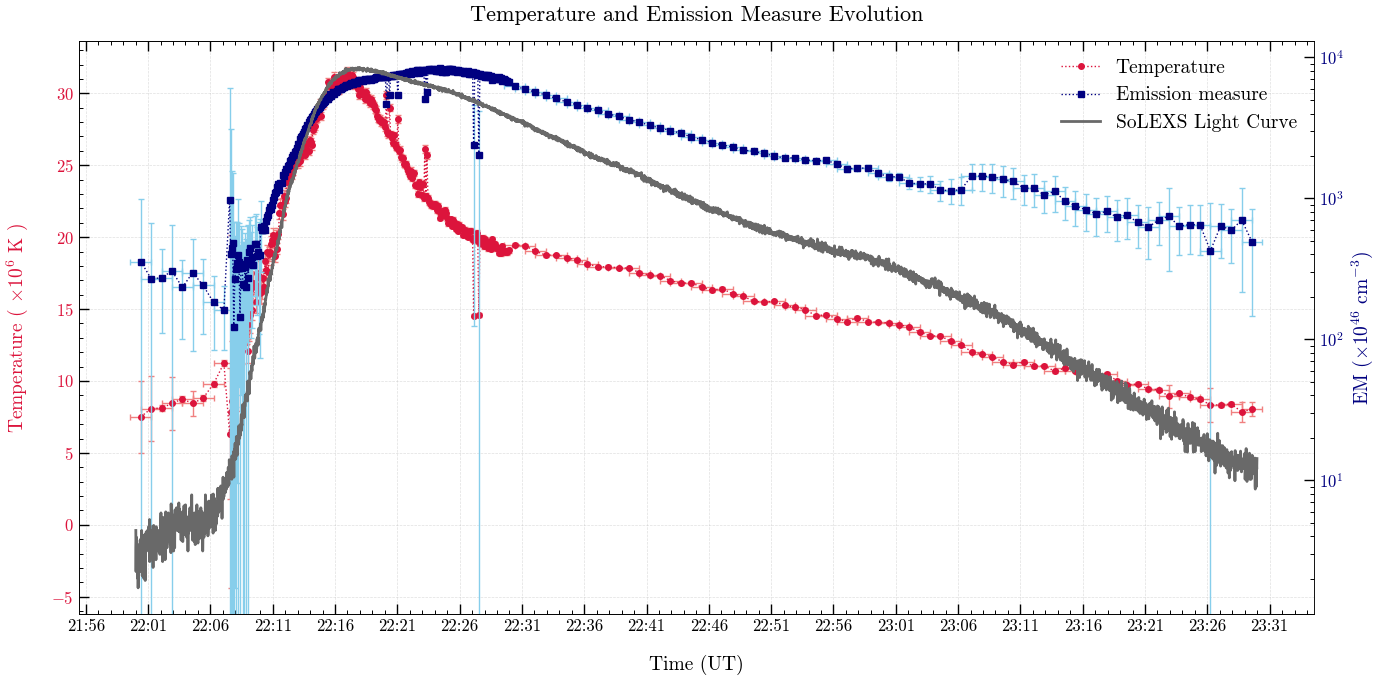

In [38]:
import pandas as pd
from datetime import datetime
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, AutoMinorLocator
import numpy as np
from astropy.io import fits
import os
import matplotlib.dates as mdates

# Define paths
new_lc_filename = '/home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Lightcurve_data/AL1_SOLEXS_20241001_SDD2_L1_2.8_12keV_tbin1s.lc'
output_plots_dir = '/home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Fitting_plots'
output_results_dir = '/home/idies/workspace/Storage/Prakhar_Singh/persistent/Data_2/Output_data/Fitting_data_results'

# First, load the fitting results
results_csv_path = os.path.join(output_results_dir, 'fitting_results.csv')
results_df = pd.read_csv(results_csv_path)

# Convert tstart and tstop to datetime objects
results_df['tstart_dt'] = pd.to_datetime(results_df['tstart'])
results_df['tstop_dt'] = pd.to_datetime(results_df['tstop'])

# Compute mid-time as datetime
results_df['mid_time_dt'] = results_df['tstart_dt'] + (results_df['tstop_dt'] - results_df['tstart_dt']) / 2

# Now define time range for Light curve plotting
t_start_lc = results_df['tstart_dt'].iloc[0]
t_end_lc = results_df['tstop_dt'].iloc[-1]

# Read light curve data
lc_hdul = fits.open(new_lc_filename)
plot_times_UNIX = lc_hdul[1].data['TIME']  # Unix seconds
plot_lcurve = lc_hdul[1].data['COUNTS']

# Convert to datetime
plot_times_dt = pd.to_datetime(plot_times_UNIX, unit='s')

# Filter LC data using pandas datetime comparison
idx = (plot_times_dt > t_start_lc) & (plot_times_dt < t_end_lc)

# Create figure with three y-axes
fig, ax1 = plt.subplots(figsize=(14, 7))
ax2 = ax1.twinx()
ax3 = ax1.twinx()

# Plot Temperature vs mid_time_dt
line1 = ax1.errorbar(
    results_df['mid_time_dt'],
    (10**(results_df['temperature'])) / 1e6,
    xerr=pd.to_timedelta(results_df['t_error'], unit='s'),  # Convert error to timedelta
    yerr=(np.log(10) * results_df['temperature_error'] * (10**results_df['temperature'])) / 1e6,
    linestyle=':', marker='o', markersize=4,
    color='crimson', capsize=2, label='Temperature', ecolor='lightcoral'
)

# Plot EM vs mid_time_dt
line2 = ax2.errorbar(
    results_df['mid_time_dt'],
    results_df['EM'],
    yerr=results_df['EM_error'],
    xerr=pd.to_timedelta(results_df['t_error'], unit='s'),
    linestyle=':', marker='s', markersize=4,
    color='navy', capsize=2, label='EM', ecolor='skyblue'
)

# Plot Light Curve vs plot_times_dt
line3 = ax3.plot(
    plot_times_dt[idx],
    plot_lcurve[idx],
    color='dimgray',
    label='Light Curve',
    linewidth=2
)

# Adjust third axis (light curve)
ax3.set_yscale('log')
ax3.set_yticklabels([])
ax3.set_ylabel('')
ax3.spines['right'].set_position(('outward', 60))
ax3.spines['right'].set_visible(False)

# Set labels and colors with increased font size
ax1.set_xlabel('Time (UT)', fontsize=14, labelpad=15)
ax1.set_ylabel('Temperature ( ×10$^{6}$ K )', color='crimson', fontsize=14, labelpad=15)
ax1.tick_params(axis='y', labelcolor='crimson', labelsize=12)
ax1.tick_params(axis='x', labelsize=12)

ax2.set_ylabel('EM (×10$^{46}$ cm$^{-3}$)', color='navy', fontsize=14)
ax2.tick_params(axis='y', labelcolor='navy', labelsize=12)
ax2.set_yscale('log')

# Format x-axis to show time labels nicely
import matplotlib.dates as mdates

# Set up x-axis formatting
time_start = results_df['mid_time_dt'].min()
time_end = results_df['mid_time_dt'].max()

# Define major ticks every 5 minutes, minor ticks every 1 minute
ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax1.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))  # Changed this line
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Make minor ticks more visible
ax1.tick_params(which='minor', length=4, color='k', width=0.5)
ax1.tick_params(which='major', length=8, color='k', width=1)

# Optional: set xlim to ensure full control over displayed time range
x_min, x_max = results_df['mid_time_dt'].min(), results_df['mid_time_dt'].max()
buffer_time = pd.Timedelta(seconds=300)  # Just a small buffer
ax1.set_xlim(x_min - buffer_time, x_max + buffer_time)

# Rotate and align the tick labels so they look better
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0, ha='center')

# Rotate and align the tick labels so they look better
#fig.autofmt_xdate(rotation=45,centre)

# Add title
plt.title('Temperature and Emission Measure Evolution', fontsize=16, pad=15)

# Add legend
lines = [line1[0]] + [line2[0]] + line3
labels = ['Temperature', 'Emission measure', 'SoLEXS Light Curve']
ax1.legend(lines, labels, loc='upper right', fontsize=14, framealpha=0)

# Add grid
ax1.grid(True, linestyle='--', alpha=0.4)

# Tick styling
ax1.tick_params(which='major', direction='in', top=True, right=False, length=7, width=1)
ax1.tick_params(which='minor', direction='in', top=True, right=False, length=3, width=0.7)
#ax1.minorticks_on()
ax1.yaxis.set_minor_locator(AutoMinorLocator(n=5))

ax2.tick_params(which='major', direction='in', top=False, right=True, length=7, width=1)
ax2.tick_params(which='minor', direction='in', top=False, right=True, length=3, width=0.7)
 # 1 minute minor ticks

# Adjust layout
plt.tight_layout()

# Show plot
plt.show()

## Elemental Abundances Plot

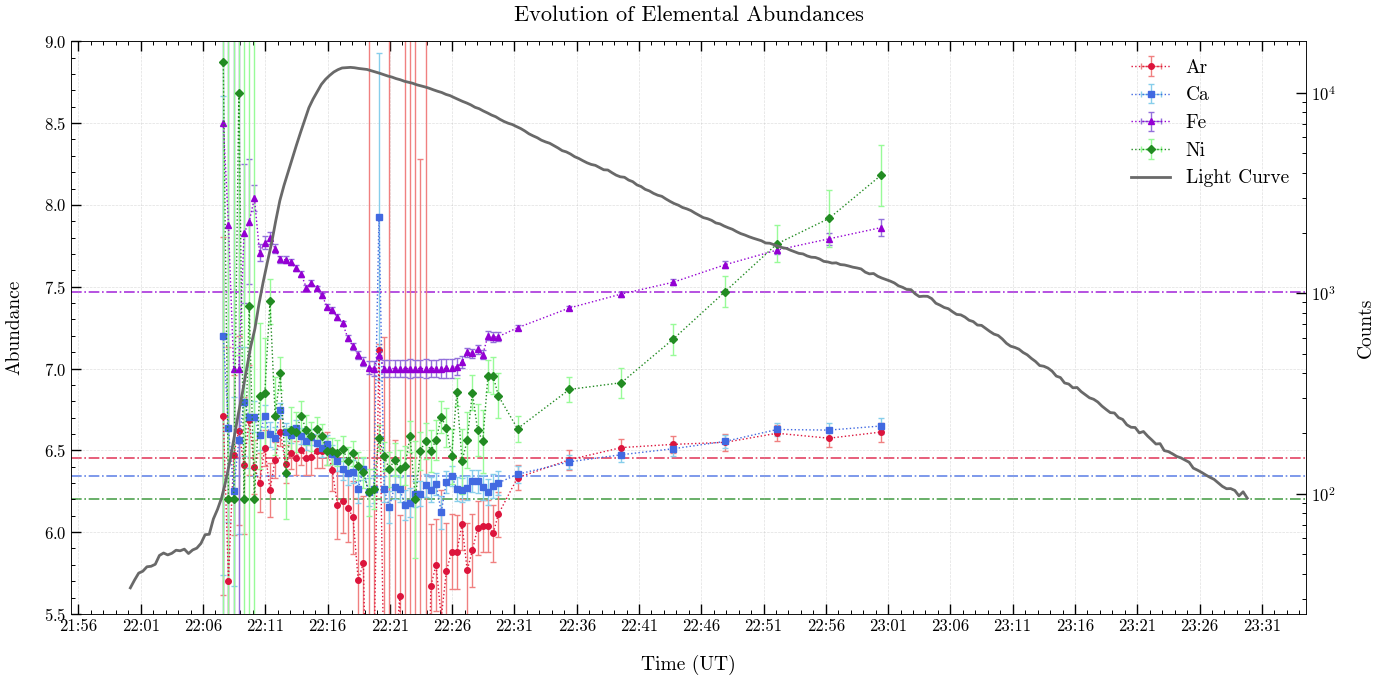

In [20]:
# Define photospheric abundance values (example values – replace with real ones)
photospheric_values = {
    'Ar': 6.45,
    'Ca': 6.34,
    'Fe': 7.47,
    'Ni': 6.2
}

# Plot elemental abundances
elements = ['Ar', 'Ca', 'Fe', 'Ni']
markers = ['o', 's', '^', 'D']
colors = ['crimson', 'royalblue', 'darkviolet', 'forestgreen']
ecolor = ['lightcoral', 'skyblue', 'mediumpurple', 'palegreen']

# First y-axis for elemental abundances
fig = plt.figure(figsize=(14, 7))
ax1 = fig.add_subplot(111)

tmin=10
tmax=320


# Plot abundances
for i, (element, marker, color) in enumerate(zip(elements, markers, colors)):
    '''
    ax1.errorbar(results_df['mid_time_dt'][tmin:tmax], 
                 results_df[f'{element}_abundance'][tmin:tmax], 
                 xerr=pd.to_timedelta(results_df['t_error'][tmin:tmax]),
                 yerr=results_df[f'{element}_abundance_error'][tmin:tmax],
                 linestyle=':',
                 marker=marker,
                 markersize=4,
                 color=color,
                 label=element,
                 ecolor=ecolor[i], 
                 capsize=2)

    '''
    ax1.errorbar(
        results_df['mid_time_dt'][tmin:tmax].iloc[::5],
        results_df[f'{element}_abundance'][tmin:tmax].iloc[::5],
        xerr=pd.to_timedelta(results_df['t_error'][tmin:tmax].iloc[::5]),
        yerr=np.abs(results_df[f'{element}_abundance_error'][tmin:tmax].iloc[::5]),
        linestyle=':',
        marker=marker,
        markersize=4,
        color=color,
        label=element,
        ecolor=ecolor[i],
        capsize=2
    )

    
    # Draw horizontal line at photospheric value
    ax1.axhline(y=photospheric_values[element], 
                color=color, 
                linestyle='-.', 
                linewidth=1.2, 
                alpha=0.8,
                zorder=0)  # zorder ensures data points stay on top

# Configure primary axis (abundances)
ax1.set_xlabel('Time (UT)', fontsize=14, labelpad=15) 
ax1.set_ylabel('Abundance', fontsize=14, labelpad=15)
ax1.tick_params(axis='x', labelsize=12)
ax1.tick_params(axis='y', labelsize=12)
ax1.grid(True, linestyle='--', alpha=0.4)
ax1.set_ylim(5.5, 9)

# Configure time axis
import matplotlib.dates as mdates

ax1.xaxis.set_major_locator(mdates.MinuteLocator(interval=5))
ax1.xaxis.set_minor_locator(mdates.MinuteLocator(interval=1))
ax1.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))

# Second y-axis for light curve
ax2 = ax1.twinx()
ax2.plot(plot_times_dt[idx],
         plot_lcurve[idx],
         color='dimgray',
         linestyle='-',
         label='Light Curve',
         linewidth=2)

# Configure secondary axis (light curve)
ax2.set_ylabel('Counts', fontsize=14, labelpad=15)
ax2.tick_params(axis='y', labelsize=12) 
ax2.set_yscale('log')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=14, framealpha=0)

# Configure tick parameters
ax1.tick_params(which='major', direction='in', top=True, right=False, length=7, width=1)
ax1.tick_params(which='minor', direction='in', top=True, right=False, length=3, width=0.7)
ax1.yaxis.set_minor_locator(AutoMinorLocator(n=5))      

ax2.tick_params(which='major', direction='in', top=False, right=True, length=7, width=1)
ax2.tick_params(which='minor', direction='in', top=False, right=True, length=3, width=0.7)

# Set time limits with buffer
x_min, x_max = results_df['mid_time_dt'].min(), results_df['mid_time_dt'].max()
buffer_time = pd.Timedelta(seconds=300)  # Just a small buffer
ax1.set_xlim(x_min - buffer_time, x_max + buffer_time)

# Rotate and align time labels
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=0, ha='center')

plt.title('Evolution of Elemental Abundances', fontsize=16, pad=15)
plt.tight_layout()
plt.show()